In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

(1567, 590)
(1567, 2)
0
-1    1463
 1     104
Name: count, dtype: int64
0
0    1463
1     104
Name: count, dtype: int64


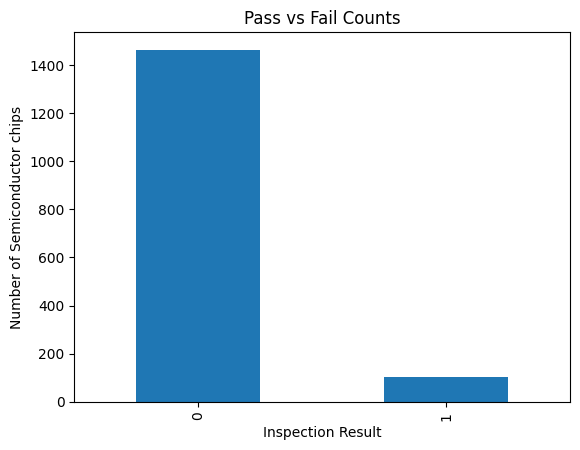

In [16]:
X= pd.read_csv("secom.data", sep= r"\s+", header=None)
labels= pd.read_csv("secom_labels.data", sep=r"\s+", header=None)
print(X.shape)
print(labels.shape)

y=labels[0]
print(y.value_counts())
y=y.replace({-1:0,1:1})
print(y.value_counts())

y.value_counts().plot(kind='bar')
plt.title('Pass vs Fail Counts')
plt.xlabel('Inspection Result')
plt.ylabel('Number of Semiconductor chips')
plt.show()

In [23]:
missing_fraction  = X.isnull().mean()
print(missing_fraction.sort_values(ascending=False).head(10))
X= X.loc[:,missing_fraction<0.5]
print(X.shape)

X= X.fillna(X.median())
print(X.isnull().sum().sum())

385    0.456286
247    0.456286
112    0.456286
519    0.456286
566    0.174218
567    0.174218
568    0.174218
569    0.174218
563    0.174218
562    0.174218
dtype: float64
(1567, 562)
0


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
lr = LogisticRegression(max_iter=1000,class_weight = 'balanced')
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91       293
           1       0.11      0.19      0.14        21

    accuracy                           0.84       314
   macro avg       0.52      0.54      0.52       314
weighted avg       0.88      0.84      0.86       314



Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9002 - loss: 0.3259 - val_accuracy: 0.9124 - val_loss: 0.2784
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9401 - loss: 0.1624 - val_accuracy: 0.9004 - val_loss: 0.2718
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9511 - loss: 0.1072 - val_accuracy: 0.9044 - val_loss: 0.2684
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9651 - loss: 0.0696 - val_accuracy: 0.9084 - val_loss: 0.2874
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9860 - loss: 0.0453 - val_accuracy: 0.9084 - val_loss: 0.3153
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9970 - loss: 0.0284 - val_accuracy: 0.9084 - val_loss: 0.3221
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9990 - loss: 0.0186 - val_accuracy: 0.9044 - val_loss: 0.3500
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0123 - val_accuracy: 0.9004 - val_l

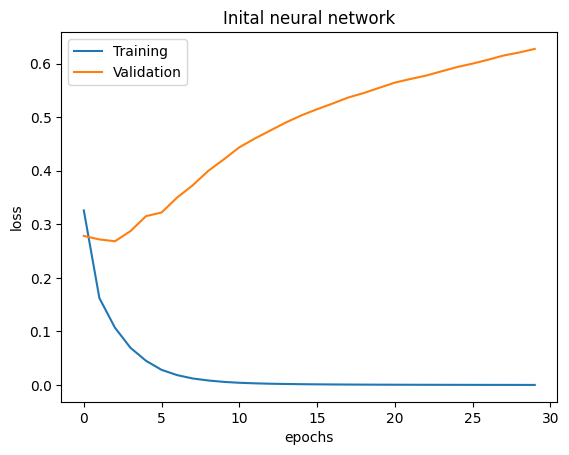

In [89]:
layer1 = Dense(128, activation='relu',input_shape = (X_train_scaled.shape[1],))
layer2 = Dense(64, activation='relu')
layer3 = Dense(1, activation='sigmoid')
NN_Model1 = Sequential([layer1,layer2,layer3])
NN_Model1.compile(optimizer= 'adam',loss= 'binary_crossentropy', metrics=['accuracy'])
history = NN_Model1.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_split = 0.2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training','Validation'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Inital neural network')
plt.show()

In [81]:
pred_prob = NN_Model1.predict(X_test_scaled)
print(pred_prob.min())
print(pred_prob.max())
print(pred_prob.mean())
pred = (pred_prob > 0.5).astype(int)
print(classification_report(y_test, pred))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
3.995711e-19
0.97866464
0.016901046
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       293
           1       0.17      0.05      0.07        21

    accuracy                           0.92       314
   macro avg       0.55      0.52      0.52       314
weighted avg       0.88      0.92      0.90       314



Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8224 - loss: 0.5592 - val_accuracy: 0.9084 - val_loss: 0.3954
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9401 - loss: 0.3042 - val_accuracy: 0.9084 - val_loss: 0.3440
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9411 - loss: 0.2440 - val_accuracy: 0.9084 - val_loss: 0.3453
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9421 - loss: 0.2080 - val_accuracy: 0.9084 - val_loss: 0.3477
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9471 - loss: 0.1831 - val_accuracy: 0.9084 - val_loss: 0.3525


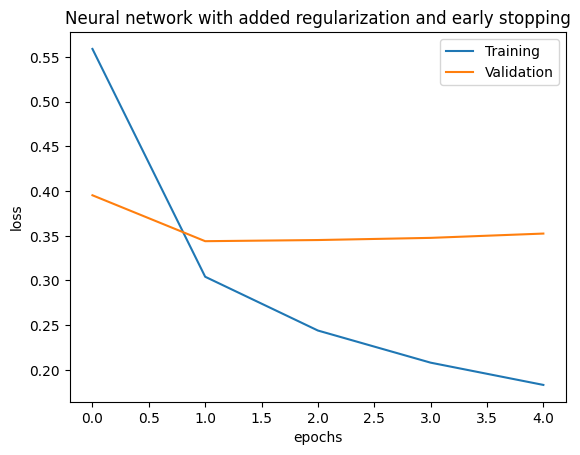

In [92]:
layer1 = Dense(32, activation='relu',input_shape = (X_train_scaled.shape[1],), kernel_regularizer = regularizers.l2(0.001))
layer2 = Dense(16, activation='relu', kernel_regularizer = regularizers.l2(0.001))
layer3 = Dense(1, activation='sigmoid')
NN_Model2 = Sequential([layer1,layer2,layer3])
NN_Model2.compile(optimizer= 'adam',loss= 'binary_crossentropy', metrics=['accuracy'])
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
history = NN_Model2.fit(X_train_scaled, y_train, epochs=30, batch_size=32, validation_split = 0.2, callbacks = [early_stop])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Neural network with added regularization and early stopping')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['Training','Validation'])
plt.show()

In [93]:
pred_prob = NN_Model2.predict(X_test_scaled)
print(pred_prob.min())
print(pred_prob.max())
print(pred_prob.mean())
print("Threshold Analysis:")
for t in [0.05, 0.1, 0.15, 0.2, 0.25]:
    pred = (pred_prob > t).astype(int)

    print("\nThreshold =", t)
    print(classification_report(y_test, pred))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
0.00014147976
0.4106009
0.084913306
Threshold Analysis:

Threshold = 0.05
              precision    recall  f1-score   support

           0       0.97      0.40      0.57       293
           1       0.09      0.81      0.16        21

    accuracy                           0.43       314
   macro avg       0.53      0.60      0.36       314
weighted avg       0.91      0.43      0.54       314


Threshold = 0.1
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       293
           1       0.08      0.38      0.14        21

    accuracy                           0.68       314
   macro avg       0.51      0.54      0.47       314
weighted avg       0.88      0.68      0.76       314


Threshold = 0.15
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       293
           1       0.11      0.24      0.15        21

    accuracy                     